In [99]:
import os
import numpy
import pandas

import matplotlib.pyplot

#### Drug warning

In [3]:
drug_warning = pandas.read_parquet("data/drug_warning/part-00000-ede10c94-333d-44c9-a6e6-df821957a172-c000.snappy.parquet")
print(f"number of entries: {len(drug_warning)}")
drug_warning.head()

number of entries: 2302


,chemblIds,toxicityClass,country,description,id,references,warningType,year,efo_term,efo_id,efo_id_for_warning_class
0,"[CHEMBL4303288, CHEMBL1380]",hepatotoxicity,United States,None,1,[{'ref_id': 'de109a2b-e36c-40d0-85fc-a67a9e7f1...,Black Box Warning,NaN,None,None,EFO:0011052
1,"[CHEMBL4303288, CHEMBL1380]",metabolic toxicity,United States,None,2,[{'ref_id': 'de109a2b-e36c-40d0-85fc-a67a9e7f1...,Black Box Warning,NaN,None,None,EFO:0011054
2,"[CHEMBL4303288, CHEMBL1380]",immune system toxicity,United States,None,3,[{'ref_id': 'de109a2b-e36c-40d0-85fc-a67a9e7f1...,Black Box Warning,NaN,None,None,EFO:0011053
3,[CHEMBL3301581],carcinogenicity,United States,None,4,[{'ref_id': '712143d9-e21e-4013-bb3b-3426a2106...,Black Box Warning,NaN,None,None,EFO:0011046
4,[CHEMBL1252],None,United States,None,5,[],Black Box Warning,NaN,None,None,None


#### Drug molecule (Drug/Clinical candidates)

In [4]:
drug_molecule = pandas.read_parquet("data/drug_molecule/part-00000-871f412e-aec4-4d33-a50d-feee532ddcd2-c000.snappy.parquet")
print(f"number of drugs: {len(drug_molecule)}")
drug_molecule.head()

number of drugs: 18475


,id,canonicalSmiles,inchiKey,drugType,blackBoxWarning,name,yearOfFirstApproval,maximumClinicalTrialPhase,parentId,hasBeenWithdrawn,isApproved,tradeNames,synonyms,crossReferences,childChemblIds,linkedDiseases,linkedTargets,description
0,CHEMBL1000,O=C(O)COCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1,ZKLPARSLTMPFCP-UHFFFAOYSA-N,Small molecule,False,CETIRIZINE,1995.0,4.0,None,False,True,[],"[AC-170, Cetiderm, Cetirizina, Cetirizine]","[{'source': 'drugbank', 'ids': ['DB00341']}]","[CHEMBL1201113, CHEMBL1607273]","{'rows': ['EFO_0008521', 'HP_0000989', 'EFO_00...","{'rows': ['ENSG00000196639'], 'count': 1}",Small molecule drug with a maximum clinical tr...
1,CHEMBL100014,CCCC(=O)OCOC(=O)C(C)(C)C,GYKLFBYWXZYSOW-UHFFFAOYSA-N,Small molecule,False,AN-9,NaN,2.0,None,False,False,[],"[An-9, Butyric acid 2,2-dimethyl-propionyloxym...","[{'source': 'drugbank', 'ids': ['DB05103']}]",None,"{'rows': ['EFO_0003060', 'EFO_0000095', 'EFO_0...",None,Small molecule drug with a maximum clinical tr...
2,CHEMBL100109,CC(=O)N[C@H](Cc1ccccc1)C(=O)N1CCC[C@H]1C(=O)N[...,UCQIHCRMWNRFNP-QYZOEREBSA-N,Small molecule,False,CHEMBL100109,NaN,NaN,None,False,None,[],[],"[{'source': 'drugbank', 'ids': ['DB07658']}]",[CHEMBL3038261],None,None,Small molecule drug.
3,CHEMBL100116,CC(C)=CCN1CCC2(C)c3cc(O)ccc3CC1C2C,VOKSWYLNZZRQPF-UHFFFAOYSA-N,Small molecule,True,PENTAZOCINE,1967.0,4.0,None,False,True,[],"[Dl-pentazocine, NIH-7958, NSC-107430, Pentazo...",None,"[CHEMBL5483020, CHEMBL3989509, CHEMBL3989510]","{'rows': ['MONDO_0004985', 'HP_0012531', 'HP_0...","{'rows': ['ENSG00000147955'], 'count': 1}",Small molecule drug with a maximum clinical tr...
4,CHEMBL1002,CC(C)(C)NC[C@H](O)c1ccc(O)c(CO)c1,NDAUXUAQIAJITI-LBPRGKRZSA-N,Small molecule,True,LEVOSALBUTAMOL,1999.0,4.0,None,False,True,[],"[ASF-1096, Albuterol (r)-form, Levalbuterol, L...","[{'source': 'drugbank', 'ids': ['DB13139']}]","[CHEMBL3989693, CHEMBL1201061, CHEMBL3989589]","{'rows': ['MONDO_0004979', 'MONDO_0004979', 'E...","{'rows': ['ENSG00000169252'], 'count': 1}",Small molecule drug with a maximum clinical tr...


#### Target (gene-to-ENSG mapping)

In [53]:
target_parquet_dir = "data/target/"
parquet_files = []
for f in os.listdir(target_parquet_dir):
    if f.endswith(".parquet") or f.endswith(".snappy.parquet"):
        parquet_file = os.path.join(target_parquet_dir, f)
        parquet_files.append(parquet_file)

target = pandas.DataFrame()
for file in parquet_files:
    target = pandas.concat([target, pandas.read_parquet(file)])
target.head()

,id,approvedSymbol,biotype,transcriptIds,canonicalTranscript,canonicalExons,genomicLocation,alternativeGenes,approvedName,go,...,constraint,tep,proteinIds,dbXrefs,chemicalProbes,homologues,tractability,safetyLiabilities,pathways,tss
0,ENSG00000000457,SCYL3,protein_coding,"[ENST00000423670, ENST00000367770, ENST0000036...","{'id': 'ENST00000367771', 'chromosome': '1', '...","[169854270, 169854964, 169868928, 169869039, 1...","{'chromosome': '1', 'start': 169846981, 'end':...",None,SCY1 like pseudokinase 3,"[{'id': 'GO:0042802', 'source': 'GO_REF:000010...",...,"[{'constraintType': 'syn', 'score': 1.07690000...",None,"[{'id': 'Q8IZE3', 'source': 'uniprot_swissprot...","[{'id': '19285', 'source': 'HGNC'}, {'id': 'IP...",None,"[{'speciesId': '9606', 'speciesName': 'Human',...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,None,169893896.0
1,ENSG00000001167,NFYA,protein_coding,"[ENST00000914458, ENST00000914462, ENST0000091...","{'id': 'ENST00000341376', 'chromosome': '6', '...","[41094396, 41094497, 41091528, 41091694, 41084...","{'chromosome': '6', 'start': 41072946, 'end': ...",None,nuclear transcription factor Y subunit alpha,"[{'id': 'GO:0000785', 'source': 'GO_REF:000011...",...,"[{'constraintType': 'syn', 'score': 0.46832001...",None,"[{'id': 'P23511', 'source': 'uniprot_swissprot...","[{'id': '7804', 'source': 'HGNC'}, {'id': '4AW...",None,"[{'speciesId': '9598', 'speciesName': 'Chimpan...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,"[{'pathwayId': 'R-HSA-9614657', 'pathway': 'FO...",41072974.0
2,ENSG00000001460,STPG1,protein_coding,"[ENST00000483528, ENST00000468303, ENST0000043...","{'id': 'ENST00000337248', 'chromosome': '1', '...","[24413674, 24413782, 24369674, 24369839, 24360...","{'chromosome': '1', 'start': 24355886, 'end': ...",None,sperm tail PG-rich repeat containing 1,"[{'id': 'GO:1902110', 'source': 'GO_REF:000003...",...,"[{'constraintType': 'syn', 'score': 0.54615998...",None,"[{'id': 'Q5TH74', 'source': 'uniprot_swissprot...","[{'id': '28070', 'source': 'HGNC'}, {'id': 'IP...",None,"[{'speciesId': '9606', 'speciesName': 'Human',...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,None,24413782.0
3,ENSG00000001629,ANKIB1,protein_coding,"[ENST00000439883, ENST00000422095, ENST0000092...","{'id': 'ENST00000265742', 'chromosome': '7', '...","[92307359, 92307656, 92294889, 92295166, 92319...","{'chromosome': '7', 'start': 92245973, 'end': ...",None,ankyrin repeat and IBR domain containing 1,"[{'id': 'GO:0008270', 'source': 'GO_REF:000000...",...,"[{'constraintType': 'syn', 'score': 1.35239994...",None,"[{'id': 'Q9P2G1', 'source': 'uniprot_swissprot...","[{'id': '22215', 'source': 'HGNC'}, {'id': 'IP...",None,"[{'speciesId': '9606', 'speciesName': 'Human',...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,None,92245974.0
4,ENSG00000003096,KLHL13,protein_coding,"[ENST00000881391, ENST00000881390, ENST0000037...","{'id': 'ENST00000540167', 'chromosome': 'X', '...","[117920238, 117920370, 117919521, 117919717, 1...","{'chromosome': 'X', 'start': 117897794, 'end':...",None,kelch like family member 13,"[{'id': 'GO:0005829', 'source': 'Reactome:R-HS...",...,None,None,"[{'id': 'Q9P2N7', 'source': 'uniprot_swissprot...","[{'id': '22931', 'source': 'HGNC'}, {'id': 'R-...",None,"[{'speciesId': '9606', 'speciesName': 'Human',...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,"[{'pathwayId': 'R-HSA-983168', 'pathway': 'Ant...",118116810.0


In [67]:
# count unique in targets id and approvedSymbol and total number of entries
print(f"number of unique ENSG: {len(target['id'].unique())}")
print(f"number of unique approvedSymbol: {len(target['approvedSymbol'].unique())}")
print(f"total number of entries: {len(target)}")

number of unique ENSG: 78725
number of unique approvedSymbol: 77112
total number of entries: 78725


In [68]:
# map ENSG to gene names and vice versa
ENSG2gene_name = {}
gene_name2ENSG = {}
for index, row in target.iterrows():
    ENSG = row['id']
    gene = row['approvedSymbol']

    # some entries are incomplete
    if ENSG == gene:
        continue
    if ENSG in ENSG2gene_name:
        assert ENSG2gene_name[ENSG] == gene
    if gene in gene_name2ENSG:
        print(f"{gene} already mapped to {gene_name2ENSG[gene]}, skipping it")
        continue

    ENSG2gene_name[ENSG] = gene
    gene_name2ENSG[gene] = ENSG

assert len(ENSG2gene_name) == len(gene_name2ENSG)

Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipp

#### ChEMBL evidence

In [7]:
chembl_parquet_dir = "data/evidence_chembl/"
parquet_files = []
for f in os.listdir(chembl_parquet_dir):
    if f.endswith(".parquet") or f.endswith(".snappy.parquet"):
        parquet_file = os.path.join(chembl_parquet_dir, f)
        parquet_files.append(parquet_file)

chembl = pandas.DataFrame()
for file in parquet_files:
    chembl = pandas.concat([chembl, pandas.read_parquet(file)])
chembl.head()

,targetId,drugId,targetFromSourceId,diseaseFromSourceMappedId,clinicalPhase,clinicalStatus,cohortPhenotypes,datasourceId,datatypeId,diseaseFromSource,...,targetFromSource,urls,studyStopReasonCategories,qualityControls,diseaseId,id,evidenceDate,score,directionOnTrait,directionOnTarget
0,ENSG00000176884,CHEMBL742,Q05586,MONDO_0002050,1.0,Completed,None,chembl,known_drug,Depression,...,CHEMBL2094124,"[{'niceName': 'ClinicalTrials', 'url': 'https:...",None,[],MONDO_0002050,00009e083efc33e86e288352f5e9f619d233aee5,2017-12-01,0.1,protect,LoF
1,ENSG00000182256,CHEMBL1522,Q99928,EFO_0004698,3.0,Completed,None,chembl,known_drug,Primary Insomnia,...,CHEMBL2093872,"[{'niceName': 'ClinicalTrials', 'url': 'https:...",None,[],EFO_0004698,0000c95d2a177e3e113b95b038229b26f8321be0,2001-02-01,0.7,protect,GoF
2,ENSG00000137745,CHEMBL1433,P45452,EFO_0003818,2.0,Recruiting,None,chembl,known_drug,Pulmonary Disease Due to Mycobacteria (Diagnosis),...,CHEMBL280,"[{'niceName': 'ClinicalTrials', 'url': 'https:...",None,[],EFO_0003818,00029329f674d4523c5125001d0b8b2a40cf26db,2020-03-02,0.2,protect,LoF
3,ENSG00000119013,CHEMBL1703,O43676,MONDO_0005148,4.0,None,None,chembl,known_drug,type 2 diabetes mellitus,...,CHEMBL2363065,"[{'niceName': 'DailyMed', 'url': 'https://dail...",None,[],MONDO_0005148,000323684a05ef1c120cca8a05f9d8e9e25ebba9,None,1.0,protect,LoF
4,ENSG00000168539,CHEMBL2146146,P11229,MONDO_0005180,4.0,None,None,chembl,known_drug,parkinsonism,...,CHEMBL216,"[{'niceName': 'DailyMed', 'url': 'https://dail...",None,[],MONDO_0005180,0003513df4828fafb56ca0702fee8df36c253de7,None,1.0,protect,LoF


#### Associations - indirect (by data type)

In [8]:
associations_parquet_dir = "data/association_by_datasource_indirect/"
parquet_files = []
for f in os.listdir(associations_parquet_dir):
    if f.endswith(".parquet") or f.endswith(".snappy.parquet"):
        parquet_file = os.path.join(associations_parquet_dir, f)
        parquet_files.append(parquet_file)

associations = pandas.DataFrame()
for file in parquet_files:
    associations = pandas.concat([associations, pandas.read_parquet(file)])
associations.head()

,datatypeId,datasourceId,diseaseId,targetId,score,evidenceCount
0,literature,europepmc,EFO_0000318,ENSG00000000419,0.018238,1
1,literature,europepmc,EFO_0000318,ENSG00000000971,0.128679,3
2,literature,europepmc,EFO_0000318,ENSG00000001084,0.090936,4
3,literature,europepmc,EFO_0000318,ENSG00000001167,0.053194,2
4,literature,europepmc,EFO_0000318,ENSG00000001626,0.135362,23


### Part. 1 Generate a not-working target set

In [9]:
# identify drugs that have been withdrawn, map them to target genes (ENSG) and diseases (EFO);
# stores results in dictionaries: withdrawn_chemblID2ENSG and withdrawn_ENSG2EFO

withdrawn_chemblID2ENSG = {}
withdrawn_chemblIDEFO = {}

for index, row in drug_molecule.iterrows():
    # search only for withdrawn drugs
    if not row['hasBeenWithdrawn']:
        continue

    chemblID = row['id']

    # keep only drugs with linked targets
    if not row['linkedTargets']:
        print(f"{chemblID} has been withdrawn but has no linked targets")
        continue
    if row['linkedTargets']['count'] < 1:
        print(f"{chemblID} has been withdrawn but has no linked targets")
        continue
    targets = row['linkedTargets']['rows']  # format: {'rows': ['ENSG00000196639'], 'count': 1}

    # keep only drugs with linked diseases
    if not row['linkedDiseases']:
        print(f"{chemblID} has been withdrawn but has no linked diseases")
        continue
    diseases = row['linkedDiseases']['rows']  # format: {'rows': ['EFO_0008521', ...}
    if len(diseases) < 1:
        print(f"{chemblID} has been withdrawn but has no linked diseases")
        continue

    print(f"{chemblID} has been withdrawn for {diseases} associated with targets {targets}")

    # store withdrawn drug-target associations
    if chemblID not in withdrawn_chemblID2ENSG:
        withdrawn_chemblID2ENSG[chemblID] = []
    withdrawn_chemblID2ENSG[chemblID].extend(targets)

    # store withdrawn drug-disease associations
    if chemblID not in withdrawn_chemblIDEFO:
        withdrawn_chemblIDEFO[chemblID] = []
    withdrawn_chemblIDEFO[chemblID].extend(diseases)
    unique_diseases = set(diseases)
    withdrawn_chemblIDEFO[chemblID] = list(unique_diseases)

CHEMBL101 has been withdrawn for ['EFO_0005755' 'HP_0003326' 'HP_0002829'] associated with targets ['ENSG00000073756' 'ENSG00000095303']
CHEMBL1018 has been withdrawn but has no linked diseases
CHEMBL106258 has been withdrawn but has no linked targets
CHEMBL1077 has been withdrawn for ['HP_0200026' 'MONDO_0005129' 'EFO_0001365' 'MP_0001845' 'MONDO_0001330'
 'MP_0001845' 'MONDO_0005129' 'EFO_0005752' 'HP_0012531' 'EFO_1000906'
 'MONDO_0007935' 'EFO_0007141'] associated with targets ['ENSG00000073756' 'ENSG00000095303']
CHEMBL1089221 has been withdrawn for ['EFO_0005752' 'HP_0003326' 'HP_0002829'] associated with targets ['ENSG00000158125']
CHEMBL110691 has been withdrawn but has no linked diseases
CHEMBL1108 has been withdrawn for ['HP_0012531' 'HP_0002017' 'EFO_0005407' 'EFO_0004888'] associated with targets ['ENSG00000149295' 'ENSG00000151577' 'ENSG00000069696' 'ENSG00000102468']
CHEMBL111 has been withdrawn for ['EFO_0004329' 'EFO_0001073' 'HP_0001397' 'EFO_1001121' 'MONDO_0008300'
 

In [10]:
# print information about targets associated with withdrawn drugs
print(f"Found {len(withdrawn_chemblID2ENSG)} targets associated with withdrawn drugs:")

for target, disease_efos in withdrawn_chemblID2ENSG.items():
    unique_diseases = set(disease_efos)
    print(f"{target} is associated with {len(unique_diseases)} diseases")

Found 122 targets associated with withdrawn drugs:
CHEMBL101 is associated with 2 diseases
CHEMBL1077 is associated with 2 diseases
CHEMBL1089221 is associated with 1 diseases
CHEMBL1108 is associated with 4 diseases
CHEMBL111 is associated with 1 diseases
CHEMBL1123 is associated with 2 diseases
CHEMBL1194666 is associated with 2 diseases
CHEMBL1200492 is associated with 4 diseases
CHEMBL1200848 is associated with 1 diseases
CHEMBL1200890 is associated with 1 diseases
CHEMBL1201115 is associated with 2 diseases
CHEMBL1201168 is associated with 2 diseases
CHEMBL1201506 is associated with 1 diseases
CHEMBL1201575 is associated with 2 diseases
CHEMBL1201605 is associated with 3 diseases
CHEMBL1201619 is associated with 2 diseases
CHEMBL121 is associated with 1 diseases
CHEMBL1213351 is associated with 1 diseases
CHEMBL122 is associated with 1 diseases
CHEMBL1228 is associated with 2 diseases
CHEMBL1237104 is associated with 1 diseases
CHEMBL1242 is associated with 10 diseases
CHEMBL12566

In [11]:
# drug_warning['chemblIds'].to_list() is a list of arrays, make it a flat list
drug_warning_list = drug_warning['chemblIds'].explode().to_list()
with_warning_count = 0
for chemblID in withdrawn_chemblID2ENSG:
    if chemblID in drug_warning_list:
        with_warning_count += 1
print(f"{with_warning_count} out of {len(withdrawn_chemblID2ENSG)} drugs (from drug-target pairs) have warnings")

121 out of 122 drugs (from drug-target pairs) have warnings


In [12]:
# find diseases with many withdrawn drugs
disease_drug_count = {}
for chemblID, diseases in withdrawn_chemblIDEFO.items():
    for disease in diseases:
        if disease not in disease_drug_count:
            disease_drug_count[disease] = 0
        disease_drug_count[disease] += 1

sorted_disease_drug_count = sorted(disease_drug_count.items(), key=lambda x: x[1], reverse=True)
print("Top 10 diseases with most withdrawn drugs:")
for disease, count in sorted_disease_drug_count[:10]:
    print(f"{disease}: {count} withdrawn drugs")

Top 10 diseases with most withdrawn drugs:
HP_0012531: 21 withdrawn drugs
EFO_0000319: 17 withdrawn drugs
EFO_0005755: 12 withdrawn drugs
EFO_0001073: 12 withdrawn drugs
EFO_0003890: 12 withdrawn drugs
MONDO_0002009: 10 withdrawn drugs
MONDO_0004979: 8 withdrawn drugs
EFO_0000400: 7 withdrawn drugs
MONDO_0005148: 6 withdrawn drugs
EFO_0004616: 6 withdrawn drugs


In [13]:
# save the withdrawn drug-target-disease associations to TSV file
with open("data/withdrawn_drug_target_disease.tsv", "w") as f:
    f.write("CHEMBLID\tENSGs\tGENE_NAMEs\tEFOs\n")
    for chemblID in withdrawn_chemblID2ENSG:
        ensgs = ",".join(withdrawn_chemblID2ENSG[chemblID])
        gene_names = ",".join([ENSG2gene_name.get(ensg, "N/A") for ensg in withdrawn_chemblID2ENSG[chemblID]])
        efos = ",".join(withdrawn_chemblIDEFO.get(chemblID, []))
        f.write(f"{chemblID}\t{ensgs}\t{gene_names}\t{efos}\n")

In [14]:
# save the not working target-disease associations to TSV file
# each line corresponds to one target gene (ENSG)
with open("data/not_working_targets.tsv", "w") as f:
    f.write("ENSG\tGENE_NAME\tEFO\n")
    for chemblID in withdrawn_chemblIDEFO:
        for ENSG in withdrawn_chemblID2ENSG[chemblID]:
            gene_name = ENSG2gene_name.get(ENSG, "N/A")
            efos = ",".join(withdrawn_chemblIDEFO.get(chemblID, []))
            f.write(f"{ENSG}\t{gene_name}\t{efos}\n")

#### If needed, convert ENSG to gene name

In [15]:
ENSG = 'ENSG00000073756'

print(ENSG2gene_name[ENSG])

PTGS2


### Part. 2 Find alternative not-withdrawn treatments for new candidate targets

In [139]:
GENE = "HTR2A"
DISEASE = "MONDO_0002009"

In [140]:
gene2score = {}
scores = pandas.read_csv(f"{GENE}-{DISEASE}/scores.tsv", sep="\t")

for index, row in scores.iterrows():
    if row["GENE"] not in gene_name2ENSG:
        print(f"{row['GENE']} not found in gene_name2ENSG, skipping it")
        continue
    gene2score[row['GENE']] = row['SCORE']

print(f"Found {len(gene2score)} new candidate targets")

S-Farn-Me not found in gene_name2ENSG, skipping it
S-Farn-Me-PalmS not found in gene_name2ENSG, skipping it
S-Farn-Me-2xPalmS not found in gene_name2ENSG, skipping it
GRB2-1 not found in gene_name2ENSG, skipping it
MyrG-p-Y419-SRC not found in gene_name2ENSG, skipping it
p-S133-CREB1 not found in gene_name2ENSG, skipping it
p-T286-CAMK2A not found in gene_name2ENSG, skipping it
p-T287-CAMK2B not found in gene_name2ENSG, skipping it
p-T287-CAMK2G not found in gene_name2ENSG, skipping it
p-T287-CAMK2D not found in gene_name2ENSG, skipping it
p-4Y-PLCG1 not found in gene_name2ENSG, skipping it
SRC-1 not found in gene_name2ENSG, skipping it
EIF2C4 not found in gene_name2ENSG, skipping it
EIF2C1 not found in gene_name2ENSG, skipping it
EIF2C3 not found in gene_name2ENSG, skipping it
FGF17-1 not found in gene_name2ENSG, skipping it
FGF8-1 not found in gene_name2ENSG, skipping it
FGF5-1 not found in gene_name2ENSG, skipping it
p-6Y-EGFR not found in gene_name2ENSG, skipping it
GalHyl-COL1A2 n

In [141]:
results_sorted = sorted(gene2score.keys(), key=lambda item: gene2score[item], reverse=True)

In [142]:
# check if top 20 highest-scoring genes have other targets for the disease
top_20_genes = results_sorted[:20]
for gene in top_20_genes:
    if gene not in gene_name2ENSG:
        print(f"{gene} ({ENSG}) not found in gene_name2ENSG")
        continue

    ENSG = gene_name2ENSG[gene]

    chembl_subset = chembl[
        (chembl['targetId'] == ENSG) &
        (chembl['diseaseFromSourceMappedId'] == DISEASE)
    ]
    drug_ids = chembl_subset['drugId'].to_list()
    notWithdrawnCount = 0
    for chemblID in drug_ids:
        if chemblID not in withdrawn_chemblID2ENSG:
            notWithdrawnCount += 1
    if notWithdrawnCount > 0:
        print(f"Gene {gene} ({ENSG}) has {len(drug_ids)} drugs associated with {DISEASE}, {notWithdrawnCount} NOT withdrawn")
    else:
        print(f"Gene {gene} ({ENSG}) has {len(drug_ids)} drugs associated with {DISEASE}")

Gene PIK3R1 (ENSG00000145675) has 0 drugs associated with MONDO_0002009
Gene PIK3CA (ENSG00000121879) has 0 drugs associated with MONDO_0002009
Gene CALM1 (ENSG00000198668) has 0 drugs associated with MONDO_0002009
Gene SOS1 (ENSG00000115904) has 0 drugs associated with MONDO_0002009
Gene PIK3R2 (ENSG00000105647) has 0 drugs associated with MONDO_0002009
Gene CREB1 (ENSG00000118260) has 0 drugs associated with MONDO_0002009
Gene PTPN11 (ENSG00000179295) has 0 drugs associated with MONDO_0002009
Gene PRKACA (ENSG00000072062) has 0 drugs associated with MONDO_0002009
Gene ACTB (ENSG00000075624) has 0 drugs associated with MONDO_0002009
Gene ITGB1 (ENSG00000150093) has 0 drugs associated with MONDO_0002009
Gene PPP2R1A (ENSG00000105568) has 0 drugs associated with MONDO_0002009
Gene PPP2CA (ENSG00000113575) has 0 drugs associated with MONDO_0002009
Gene PIK3CB (ENSG00000051382) has 0 drugs associated with MONDO_0002009
Gene CTNNB1 (ENSG00000168036) has 0 drugs associated with MONDO_000200

### Part 3. Find additional evidence for new candidate target-disease associations

In [143]:
ENSG2association = {}
ENSG2evidence = {}

disease_associations = associations[associations['diseaseId'] == DISEASE]

for index, row in disease_associations.iterrows():
    ENSG = row['targetId']

    ENSG2association[ENSG] = row["score"]
    ENSG2evidence[ENSG] = row["evidenceCount"]

assert len(ENSG2association) == len(ENSG2evidence)

In [144]:
scores_sorted = []
associations_sorted = []
evidence_sorted = []

for gene in gene2score:
    if gene not in gene_name2ENSG:
        print(f"{gene} not found in gene_name2ENSG, skipping it")
        continue
    ENSG = gene_name2ENSG[gene]

    if ENSG not in ENSG2association:
        print(f"{ENSG} has no association with {DISEASE}")
        continue
    
    scores_sorted.append(gene2score[gene])
    associations_sorted.append(ENSG2association[ENSG])
    evidence_sorted.append(ENSG2evidence[ENSG])

assert len(associations_sorted) == len(evidence_sorted) == len(scores_sorted)

print(f"{len(scores_sorted)} genes have associations with {DISEASE}")

ENSG00000115904 has no association with MONDO_0002009
ENSG00000105647 has no association with MONDO_0002009
ENSG00000179295 has no association with MONDO_0002009
ENSG00000072062 has no association with MONDO_0002009
ENSG00000105568 has no association with MONDO_0002009
ENSG00000140992 has no association with MONDO_0002009
ENSG00000137713 has no association with MONDO_0002009
ENSG00000078369 has no association with MONDO_0002009
ENSG00000127588 has no association with MONDO_0002009
ENSG00000167414 has no association with MONDO_0002009
ENSG00000127920 has no association with MONDO_0002009
ENSG00000174021 has no association with MONDO_0002009
ENSG00000172354 has no association with MONDO_0002009
ENSG00000184009 has no association with MONDO_0002009
ENSG00000127928 has no association with MONDO_0002009
ENSG00000242616 has no association with MONDO_0002009
ENSG00000167083 has no association with MONDO_0002009
ENSG00000162188 has no association with MONDO_0002009
ENSG00000123104 has no assoc

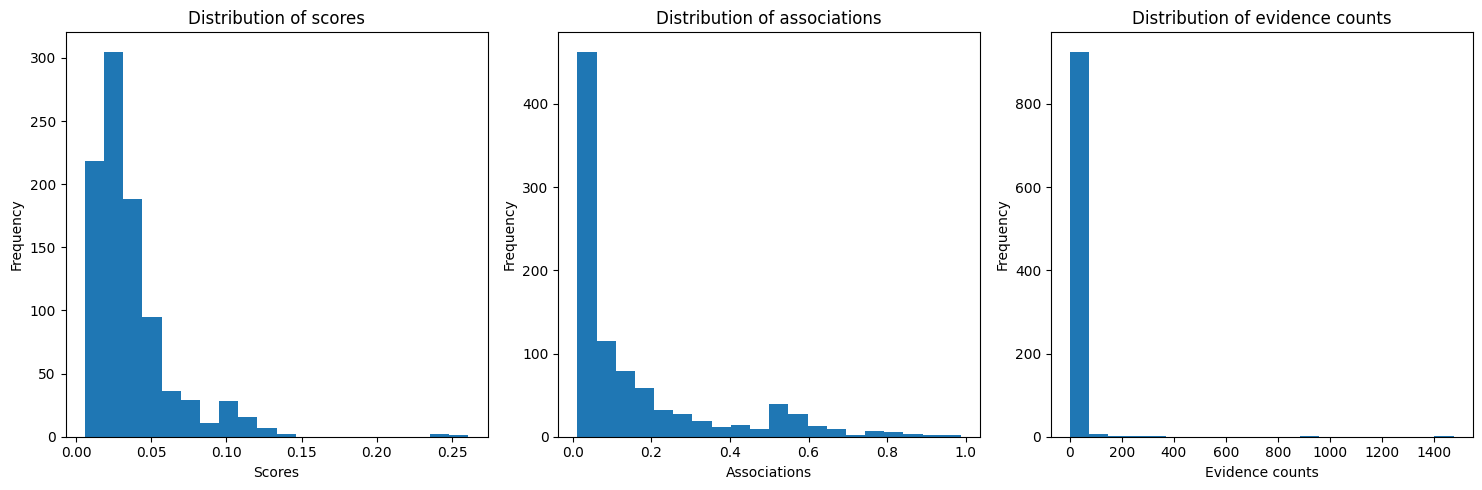

In [145]:
# 3 histograms of scores_sorted, associations_sorted and evidence_sorted
matplotlib.pyplot.figure(figsize=(15, 5))

matplotlib.pyplot.subplot(1, 3, 1)
matplotlib.pyplot.hist(scores_sorted, bins=20)
matplotlib.pyplot.xlabel("Scores")
matplotlib.pyplot.ylabel("Frequency")
matplotlib.pyplot.title("Distribution of scores")

matplotlib.pyplot.subplot(1, 3, 2)
matplotlib.pyplot.hist(associations_sorted, bins=20)
matplotlib.pyplot.xlabel("Associations")
matplotlib.pyplot.ylabel("Frequency")
matplotlib.pyplot.title("Distribution of associations")

matplotlib.pyplot.subplot(1, 3, 3)
matplotlib.pyplot.hist(evidence_sorted, bins=20)
matplotlib.pyplot.xlabel("Evidence counts")
matplotlib.pyplot.ylabel("Frequency")
matplotlib.pyplot.title("Distribution of evidence counts")

matplotlib.pyplot.tight_layout()
matplotlib.pyplot.savefig(f"{GENE}-{DISEASE}/scores-associations-evidence-hist.png")

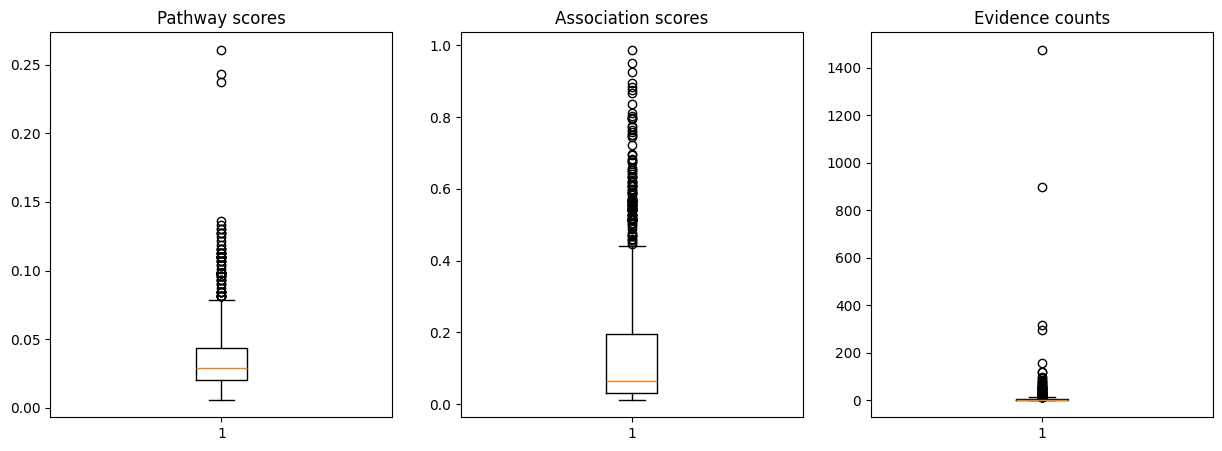

In [146]:
# 3 boxplots of scores_sorted, associations_sorted and evidence_sorted
matplotlib.pyplot.figure(figsize=(15, 5))
matplotlib.pyplot.subplot(1, 3, 1)
matplotlib.pyplot.boxplot(scores_sorted)
matplotlib.pyplot.title("Pathway scores")
matplotlib.pyplot.subplot(1, 3, 2)
matplotlib.pyplot.boxplot(associations_sorted)
matplotlib.pyplot.title("Association scores")
matplotlib.pyplot.subplot(1, 3, 3)
matplotlib.pyplot.boxplot(evidence_sorted)
matplotlib.pyplot.title("Evidence counts")

matplotlib.pyplot.savefig(f"{GENE}-{DISEASE}/scores-associations-evidence-box.png")

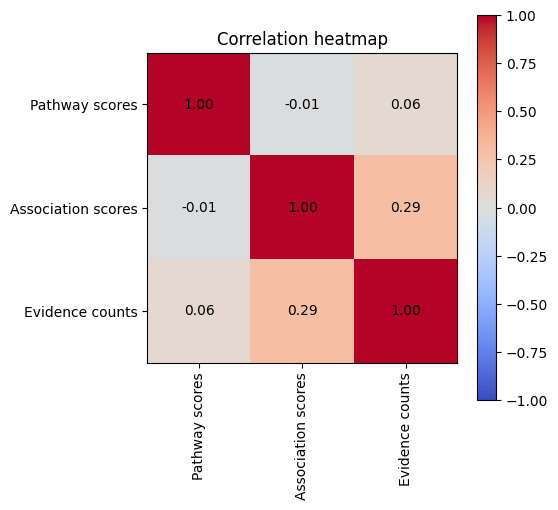

In [147]:
# correlation heatmap: scores_sorted, associations_sorted and evidence_sorted
correlation_matrix = numpy.corrcoef([scores_sorted, associations_sorted, evidence_sorted])

matplotlib.pyplot.figure(figsize=(5, 5))
matplotlib.pyplot.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# add correlation values to heatmap
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        matplotlib.pyplot.text(j, i, f"{correlation_matrix[i, j]:.2f}", ha='center', va='center', color='black')

matplotlib.pyplot.title("Correlation heatmap")
matplotlib.pyplot.xticks([0, 1, 2], ["Pathway scores", "Association scores", "Evidence counts"], rotation=90)
matplotlib.pyplot.yticks([0, 1, 2], ["Pathway scores", "Association scores", "Evidence counts"])
matplotlib.pyplot.colorbar()
matplotlib.pyplot.savefig(f"{GENE}-{DISEASE}/correlation_heatmap.png")